# Compare Fractal CNN (Keras) vs ResNet (PyTorch) with Grad-CAM and metrics

This notebook:
- Loads the 10k HDF5 dataset at /home/davas/Documents/cnn_astro/data/raw/flexible_20260412_120127_128x128_10000.h5
- Imports the existing CNN from `src/fractal_classifier_01/models`
- Builds a PyTorch ResNet50 adapted for 1-channel input
- Runs inference for both models, computes metrics, and generates Grad-CAM visualizations

Usage notes:
- Set `TF_CHECKPOINT` and `TORCH_CHECKPOINT` below if you have saved weights.
- The notebook auto-detects classification vs regression outputs and computes appropriate metrics.


In [2]:
# Setup imports and paths
import os
import sys
from pathlib import Path
import json

import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, mean_absolute_error

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T

# TensorFlow
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Add repo root to path so we can import `src` modules
REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))

# Paths
H5_PATH = Path('/home/davas/Documents/cnn_astro/data/raw/flexible_20260412_120127_128x128_10000.h5')
MODEL_SRC_DIR = REPO_ROOT / 'src' / 'fractal_classifier_01' / 'models'
OUTPUT_DIR = (REPO_ROOT / 'outputs' / 'comparison' / 'gradcam')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Checkpoint placeholders (update if you have weights)
TF_CHECKPOINT = None
TORCH_CHECKPOINT = None

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch device:', DEVICE)
print('TensorFlow device list:', tf.config.list_physical_devices())


2026-04-29 02:13:39.216974: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Torch device: cuda
TensorFlow device list: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Inspect the HDF5 dataset
with h5py.File(H5_PATH, 'r') as f:
    print('Keys:', list(f.keys()))
    # common structure: 'images' and 'parameters' or 'labels'
    if 'images' in f:
        print('images shape:', f['images'].shape, 'dtype:', f['images'].dtype)
    for k in f.keys():
        try:
            print(k, '->', dict(f[k].attrs))
        except Exception:
            pass
    # show parameters if present
    if 'parameters' in f:
        print('parameters keys:', list(f['parameters'].keys()))
    # peek first image
    if 'images' in f:
        img0 = f['images'][0]
        print('sample image min/max/mean:', float(np.min(img0)), float(np.max(img0)), float(np.mean(img0)))


Keys: ['images', 'parameters']
images shape: (10000, 128, 128) dtype: float32
images -> {}
parameters -> {}
parameters keys: ['beta', 'k_max', 'k_min', 'mean', 'ni', 'nj', 'nk', 'seed', 'sigma']
sample image min/max/mean: -2.694690704345703 1.7136847972869873 -0.4028171896934509


In [4]:
# Dataset classes and preprocessing helpers
class H5TorchDataset(Dataset):
    def __init__(self, file_path, indices, labels=None, transform=None):
        self.file_path = str(file_path)
        self.indices = np.asarray(indices, dtype=np.int64)
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_idx = int(self.indices[idx])
        with h5py.File(self.file_path, 'r') as f:
            img = f['images'][img_idx]
            # images might be HxW or HxWx1
            img = img.astype(np.float32)
        # normalize 0..1
        if img.max() > 1.0:
            img = img / 255.0
        # convert to CxHxW 3-channel by duplicating
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=0)
        elif img.shape[-1] == 1:
            img = np.transpose(img, (2,0,1)).reshape(3, img.shape[0], img.shape[1])
        else:
            img = np.transpose(img, (2,0,1))
        tensor = torch.from_numpy(img).float()
        if self.transform is not None:
            tensor = self.transform(tensor)
        if self.labels is None:
            return tensor
        return tensor, int(self.labels[img_idx])


def h5_tf_generator(file_path, indices, labels=None):
    def gen():
        with h5py.File(str(file_path),'r') as f:
            for i in indices:
                img = f['images'][int(i)].astype(np.float32)
                if img.max() > 1.0:
                    img = img / 255.0
                # ensure HxWx1
                if img.ndim == 2:
                    img = np.expand_dims(img, -1)
                if labels is None:
                    yield img
                else:
                    yield img, float(labels[int(i)])
    return gen

# preprocessing functions
from torchvision.transforms import Normalize
NORMALIZE_TORCH = T.Compose([T.Resize((128,128)),])

def preprocess_for_tf(img, target_size=(128,128)):
    import tensorflow as _tf
    img = _tf.image.resize(img, target_size)
    # ensure shape HxWx1
    if img.shape[-1] != 1:
        img = img[...,0:1]
    return img


In [5]:
# Load existing Keras fractal CNN
try:
    from src.fractal_classifier_01.models.cnn import build_fractal_cnn
    print('Imported build_fractal_cnn from src.fractal_classifier_01.models.cnn')
except Exception as e:
    print('Could not import Keras model builder:', e)
    build_fractal_cnn = None

# Instantiate a model with a guessed input shape (will adapt if possible)
def make_keras_model(input_shape=(128,128,1), num_classes=6):
    if build_fractal_cnn is None:
        raise RuntimeError('build_fractal_cnn not available; check src path')
    model = build_fractal_cnn(input_shape=input_shape, num_classes=num_classes)
    if TF_CHECKPOINT:
        model.load_weights(TF_CHECKPOINT)
    return model


Imported build_fractal_cnn from src.fractal_classifier_01.models.cnn


In [6]:
# Define a PyTorch ResNet50 classifier (1-channel input)
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes, in_channels=1, pretrained=False):
        super().__init__()
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        # adapt first conv
        self.backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

# helper to build/load ResNet
def make_resnet(num_classes, in_channels=1, pretrained=False, ckpt=None):
    model = ResNet50Classifier(num_classes=num_classes, in_channels=in_channels, pretrained=pretrained)
    model.to(DEVICE)
    if ckpt:
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    return model


In [ ]:
# Evaluation helpers
import math
from collections import defaultdict


def is_regression_output(preds):
    # preds: numpy array
    return preds.ndim == 1 or (preds.ndim == 2 and preds.shape[1] == 1)


def compute_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}


def compute_regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))
    return {'mae': mae, 'rmse': rmse}


# Torch evaluation
@torch.no_grad()
def eval_torch_model(model, dataloader, n_samples=None):
    preds = []
    targets = []
    for xb, yb in dataloader:
        xb = xb.to(DEVICE)
        out = model(xb)
        out_np = out.detach().cpu().numpy()
        preds.append(out_np)
        targets.append(yb.numpy())
        if n_samples and len(np.vstack(preds)) >= n_samples:
            break
    preds = np.vstack(preds)
    targets = np.concatenate(targets)
    if is_regression_output(preds):
        return compute_regression_metrics(targets, preds.squeeze())
    else:
        y_pred = np.argmax(preds, axis=1)
        return compute_classification_metrics(targets, y_pred)


# TF evaluation
def eval_tf_model(model, tf_dataset, n_samples=None):
    preds = []
    targets = []
    count = 0
    label_values = None
    continuous_targets = False
    if 'labels' in globals() and globals().get('labels') is not None:
        labels_obj = globals().get('labels')
        continuous_targets = getattr(labels_obj, 'dtype', None) is not None and labels_obj.dtype.kind == 'f'
        label_values = np.asarray(np.sort(np.unique(labels_obj)))
    for item in tf_dataset:
        if isinstance(item, tuple) and len(item) == 2:
            x, y = item
            y_np = np.asarray(y.numpy()).reshape(-1)
            if y_np.size:
                targets.append(y_np)
        else:
            x = item
        x = tf.convert_to_tensor(x)
        if x.shape.rank == 3:
            x = tf.expand_dims(x, 0)
        out = model(x, training=False).numpy()
        preds.append(out)
        count += 1
        if n_samples and count >= n_samples:
            break
    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets) if len(targets) > 0 else None
    if targets is None:
        return None
    if is_regression_output(preds):
        return compute_regression_metrics(targets, preds.squeeze())
    pred_idx = np.argmax(preds, axis=1)
    if continuous_targets and label_values is not None and len(label_values) >= preds.shape[1]:
        pred_vals = label_values[pred_idx]
        return compute_regression_metrics(targets, pred_vals)
    if targets.dtype.kind == 'f':
        return compute_regression_metrics(targets, pred_idx.astype(np.float32))
    return compute_classification_metrics(targets.astype(int), pred_idx.astype(int))


In [25]:
# Grad-CAM for PyTorch
import cv2

def get_gradcam_torch(model, input_tensor, target_class=None, target_layer_name='backbone.layer4'):
    model.eval()
    # find layer
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        # try common name
        target_layer = dict(model.named_modules()).get('backbone.layer4', None)
    activations = None
    gradients = None
    def forward_hook(module, inp, out):
        nonlocal activations
        activations = out.detach()
    def backward_hook(module, grad_in, grad_out):
        nonlocal gradients
        gradients = grad_out[0].detach()
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_backward_hook(backward_hook)
    input_tensor = input_tensor.to(DEVICE)
    if input_tensor.ndim == 3:
        input_tensor = input_tensor.unsqueeze(0)
    elif input_tensor.ndim != 4:
        raise ValueError(f'Expected 3D or 4D tensor for Grad-CAM, got shape {tuple(input_tensor.shape)}')
    input_tensor.requires_grad = True
    out = model(input_tensor)
    if target_class is None:
        target_class = int(out.argmax(dim=1).item())
    score = out[0, target_class]
    model.zero_grad()
    score.backward(retain_graph=True)
    weights = gradients.mean(dim=(2,3), keepdim=True)
    gcam = (weights * activations).sum(dim=1, keepdim=True)
    gcam = torch.relu(gcam)
    gcam = nn.functional.interpolate(gcam, size=(input_tensor.shape[-2], input_tensor.shape[-1]), mode='bilinear', align_corners=False)
    gcam = gcam.squeeze().cpu().numpy()
    # cleanup
    handle_f.remove(); handle_b.remove()
    # normalize
    gcam = (gcam - gcam.min()) / (gcam.max() - gcam.min() + 1e-8)
    return gcam

# Grad-CAM for TensorFlow (Keras)
def get_gradcam_tf(keras_model, input_image, target_class=None, last_conv_layer_name=None):
    # keras_model: tf.keras.Model
    img = tf.convert_to_tensor(input_image[np.newaxis,...], dtype=tf.float32)
    if last_conv_layer_name is None:
        # try to find a conv layer
        for layer in reversed(keras_model.layers):
            if 'conv' in layer.name:
                last_conv_layer_name = layer.name
                break
    last_conv = keras_model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model([keras_model.inputs], [last_conv.output, keras_model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        if target_class is None:
            target_class = tf.argmax(predictions[0])
        loss = predictions[:, target_class]
    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(1,2))
    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, tf.newaxis, :], conv_outputs), axis=-1)
    cam = tf.nn.relu(cam)
    cam = cam[0].numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam = cv2.resize(cam, (input_image.shape[1], input_image.shape[0]))
    return cam


In [26]:
# Visualization helper
import matplotlib.cm as cm

def overlay_heatmap(image, heatmap, alpha=0.5, cmap='jet'):
    # image: HxW or HxWx1 or CxHxW
    if image.ndim == 3 and image.shape[0] in (1,3):
        img = np.transpose(image, (1,2,0)) if image.shape[0] != image.shape[2] else image
    elif image.ndim == 2:
        img = image
    else:
        img = image[...,0]
    heatmap_rgb = cm.get_cmap(cmap)(heatmap)[:,:,:3]
    heatmap_rgb = (heatmap_rgb * 255).astype(np.uint8)
    if img.max() <= 1.0:
        img_disp = (img*255).astype(np.uint8)
    else:
        img_disp = img.astype(np.uint8)
    if img_disp.ndim == 2:
        img_disp_color = cv2.cvtColor(img_disp, cv2.COLOR_GRAY2RGB)
    else:
        img_disp_color = img_disp
    overlay = cv2.addWeighted(img_disp_color, 1-alpha, heatmap_rgb, alpha, 0)
    return overlay


In [28]:
# Run evaluation and save metrics + example Grad-CAMs
from sklearn.model_selection import train_test_split

# Quick helper to read labels if present
with h5py.File(H5_PATH, 'r') as f:
    n_images = int(f['images'].shape[0])
    labels = None
    if 'labels' in f:
        labels = f['labels'][:]
    elif 'parameters' in f and 'k_min' in f['parameters']:
        labels = f['parameters']['k_min'][:]
    else:
        if 'parameters' in f:
            pk = list(f['parameters'].keys())[0]
            labels = f['parameters'][pk][:]

print('n_images', n_images)

# use a test split
idx = np.arange(n_images)

# determine stratify array safely
if 'stratify_target' in globals() and stratify_target is not None:
    stratify_arr = stratify_target
else:
    stratify_arr = None
    if labels is not None and getattr(labels, 'ndim', None) == 1 and len(np.unique(labels)) > 1:
        uniq = len(np.unique(labels))
        if uniq > 20:
            stratify_arr = np.digitize(labels, np.quantile(labels, np.linspace(0, 1, 11)), right=True)
        else:
            stratify_arr = labels

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=(stratify_arr if stratify_arr is not None else None),
)

# build datasets and loaders
TEST_INDICES = test_idx
BATCH = 32
torch_test_ds = H5TorchDataset(H5_PATH, TEST_INDICES, labels)
test_loader = DataLoader(torch_test_ds, batch_size=BATCH, shuffle=False)

# Build models
label_values = np.asarray(np.sort(np.unique(labels))) if labels is not None else None
continuous_labels = labels is not None and getattr(labels, 'dtype', None) is not None and labels.dtype.kind == 'f'
num_classes = int(len(label_values)) if label_values is not None and (continuous_labels or len(label_values) > 2) else 1
print('Num classes guess:', num_classes)
print('Continuous labels:', continuous_labels)

keras_model = None
try:
    if build_fractal_cnn:
        keras_model = make_keras_model(input_shape=(128, 128, 1), num_classes=num_classes)
        print('Keras model built')
except Exception as e:
    print('Keras build error:', e)

torch_model = make_resnet(num_classes=num_classes, in_channels=1, pretrained=False, ckpt=TORCH_CHECKPOINT)
print('Torch model prepared')


def _pred_to_label_values(pred_indices):
    if label_values is not None and len(label_values) > int(np.max(pred_indices, initial=0)):
        return label_values[pred_indices.astype(int)]
    return pred_indices


# Evaluate torch model
torch_model.to(DEVICE)
torch_model.eval()
all_torch_targets = []
all_torch_preds = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        yb_np = yb.numpy()
        if xb.ndim == 4 and xb.shape[1] == 3 and getattr(torch_model.backbone.conv1, 'in_channels', 1) == 1:
            xb = xb.mean(dim=1, keepdim=True)
        out = torch_model(xb)
        if out.ndim > 1 and out.shape[1] > 1:
            pred_idx = out.argmax(dim=1).detach().cpu().numpy()
            pred_vals = _pred_to_label_values(pred_idx)
            if continuous_labels:
                all_torch_targets.append(yb_np.reshape(-1))
                all_torch_preds.append(np.asarray(pred_vals).reshape(-1))
            else:
                all_torch_targets.append(yb_np.reshape(-1).astype(int))
                all_torch_preds.append(pred_idx.reshape(-1).astype(int))
        else:
            pred_vals = out.detach().cpu().numpy().reshape(-1)
            all_torch_targets.append(yb_np.reshape(-1))
            all_torch_preds.append(pred_vals)

all_torch_targets = np.concatenate(all_torch_targets) if all_torch_targets else np.array([])
all_torch_preds = np.concatenate(all_torch_preds) if all_torch_preds else np.array([])

if continuous_labels or is_regression_output(np.asarray(all_torch_preds)):
    torch_metrics = compute_regression_metrics(all_torch_targets, all_torch_preds)
else:
    torch_metrics = compute_classification_metrics(all_torch_targets.astype(int), all_torch_preds.astype(int))
print('Torch metrics:', torch_metrics)

# Prepare TF dataset for keras eval using fixed shapes, and evaluate inline so this cell works independently
if keras_model is not None:
    def _tf_fixed_shape_generator():
        with h5py.File(H5_PATH, 'r') as f:
            for i in TEST_INDICES:
                img = f['images'][int(i)].astype(np.float32)
                if img.max() > 1.0:
                    img = img / 255.0
                if img.ndim == 2:
                    img = img[..., np.newaxis]
                elif img.ndim == 3 and img.shape[-1] != 1:
                    img = img[..., 0:1]
                y_val = np.float32(labels[int(i)]) if labels is not None else np.float32(0.0)
                yield img, y_val

    tf_output_signature = (
        tf.TensorSpec(shape=(128, 128, 1), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.float32),
    )
    tf_ds = tf.data.Dataset.from_generator(_tf_fixed_shape_generator, output_signature=tf_output_signature)
    tf_ds = tf_ds.batch(1)

    tf_preds = []
    tf_targets = []
    for x_batch, y_batch in tf_ds:
        out = keras_model(x_batch, training=False).numpy()
        tf_preds.append(out)
        tf_targets.append(np.asarray(y_batch.numpy()).reshape(-1))

    tf_preds = np.concatenate(tf_preds, axis=0)
    tf_targets = np.concatenate(tf_targets)
    tf_pred_idx = np.argmax(tf_preds, axis=1)
    tf_pred_vals = _pred_to_label_values(tf_pred_idx)

    if continuous_labels or is_regression_output(tf_preds):
        tf_metrics = compute_regression_metrics(tf_targets, tf_pred_vals)
    else:
        tf_metrics = compute_classification_metrics(tf_targets.astype(int), tf_pred_idx.astype(int))
    print('TF metrics:', tf_metrics)

# Save metrics summary
metrics = {'torch': torch_metrics, 'tf': tf_metrics if keras_model else None}
with open(OUTPUT_DIR / 'metrics_summary.json', 'w') as fh:
    json.dump(metrics, fh, indent=2)
print('Saved metrics to', OUTPUT_DIR / 'metrics_summary.json')

# Create a few Grad-CAM visualizations for the first 8 test samples
n_show = min(8, len(TEST_INDICES))
for i in range(n_show):
    idx_img = int(TEST_INDICES[i])
    with h5py.File(H5_PATH, 'r') as f:
        img = f['images'][idx_img]

    t_img = np.asarray(img, dtype=np.float32)
    if t_img.ndim == 2:
        t_img = t_img[..., np.newaxis]
    elif t_img.ndim == 3 and t_img.shape[-1] != 1:
        t_img = t_img[..., 0:1]
    t_tensor = torch.from_numpy(t_img).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    if keras_model is not None:
        tf_img = np.asarray(img, dtype=np.float32)
        if tf_img.ndim == 2:
            tf_img = tf_img[..., np.newaxis]
        elif tf_img.ndim == 3 and tf_img.shape[-1] != 1:
            tf_img = tf_img[..., 0:1]
        gcam_tf = get_gradcam_tf(keras_model, tf_img)
        overlay_tf = overlay_heatmap(tf_img[..., 0], gcam_tf)
        plt.imsave(str(OUTPUT_DIR / f'gradcam_tf_{i}.png'), overlay_tf)

    gcam_t = get_gradcam_torch(torch_model, t_tensor, target_class=None)
    overlay_t = overlay_heatmap(t_img[..., 0], gcam_t)
    plt.imsave(str(OUTPUT_DIR / f'gradcam_torch_{i}.png'), overlay_t)

print('Saved example Grad-CAMs to', OUTPUT_DIR)


n_images 10000
Num classes guess: 9998
Continuous labels: True
Keras model built
Torch model prepared
Torch metrics: {'mae': 12.89309024810791, 'rmse': 15.36129719667238}


2026-04-29 02:41:32.325189: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/davas/.uve/py311/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input']]
Received: inputs=['Tensor(shape=(1, 128, 128, 1))']
  warnings.warn(msg)
/tmp/ipykernel_18242/1519263701.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap_rgb = cm.get_cmap(cmap)(heatmap)[:,:,:3]
/home/davas/.uve/py311/lib/python3.11/site-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_inpu

TF metrics: {'mae': 13.607050895690918, 'rmse': 15.168402827454758}
Saved metrics to /home/davas/Documents/cnn_astro/outputs/comparison/gradcam/metrics_summary.json
Saved example Grad-CAMs to /home/davas/Documents/cnn_astro/outputs/comparison/gradcam


In [29]:
# Recompute a safe train/test split (overrides previous split) to avoid stratify errors
from sklearn.model_selection import train_test_split

idx = np.arange(n_images)
stratify_target = None
if labels is not None and getattr(labels, 'ndim', None) == 1:
    unique_vals = np.unique(labels)
    if labels.dtype.kind in 'iu' and len(unique_vals) >= 2:
        stratify_target = labels
    else:
        try:
            import pandas as pd
            n_bins = min(10, max(2, int(len(labels) // 1000) or 10))
            stratify_target = pd.qcut(labels, q=n_bins, duplicates='drop', labels=False)
            stratify_target = np.asarray(stratify_target)
            vals, counts = np.unique(stratify_target, return_counts=True)
            if np.any(counts < 2):
                stratify_target = None
        except Exception:
            stratify_target = None

print('Stratify target set?', stratify_target is not None)
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=stratify_target)
TEST_INDICES = test_idx
# Rebuild torch test loader (override previous)
torch_test_ds = H5TorchDataset(H5_PATH, TEST_INDICES, labels)
test_loader = DataLoader(torch_test_ds, batch_size=BATCH, shuffle=False)
print('Recomputed split. test samples:', len(TEST_INDICES))


Stratify target set? True
Recomputed split. test samples: 2000


## Poster-Ready Figures

The next cell generates compact, high-contrast figures for a poster: metric bars, prediction parity, residual distributions, and a small Grad-CAM comparison strip.

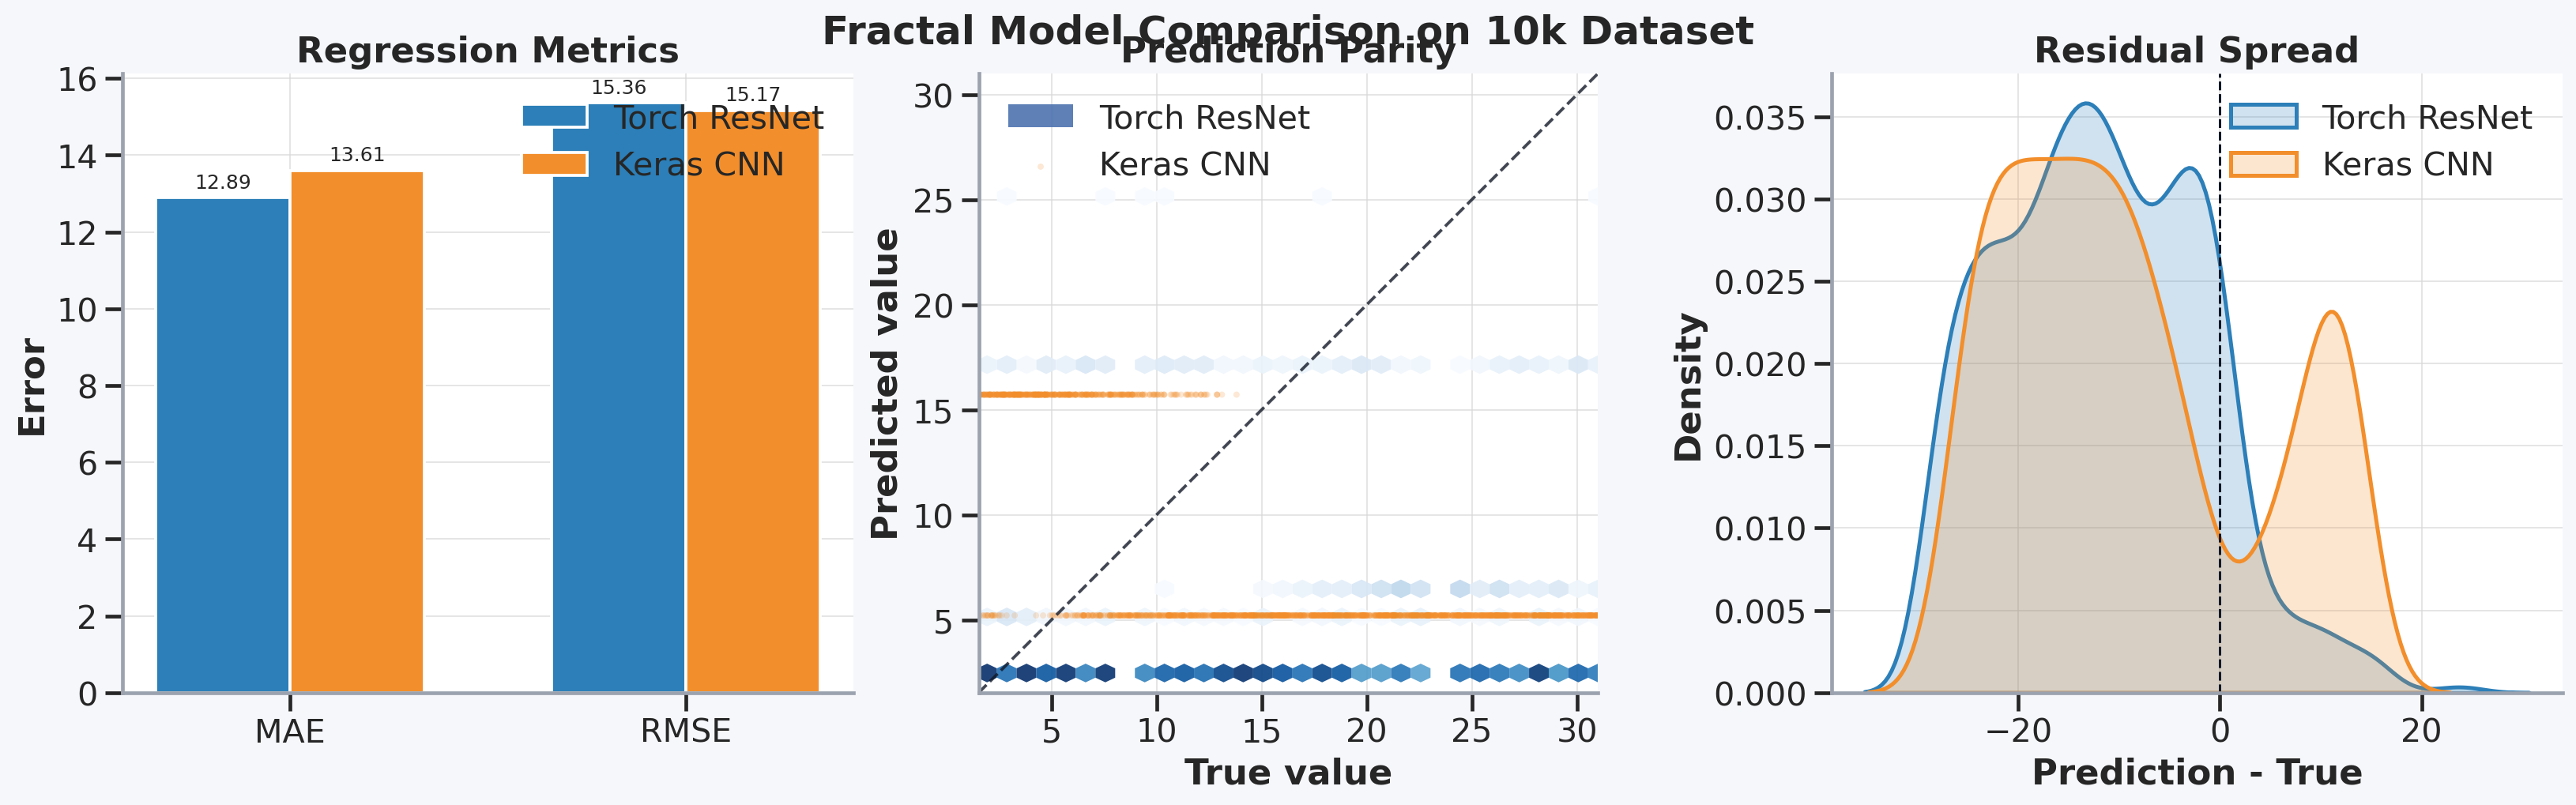

/home/davas/.uve/py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*args, out=...)
/home/davas/.uve/py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*args, out=...)


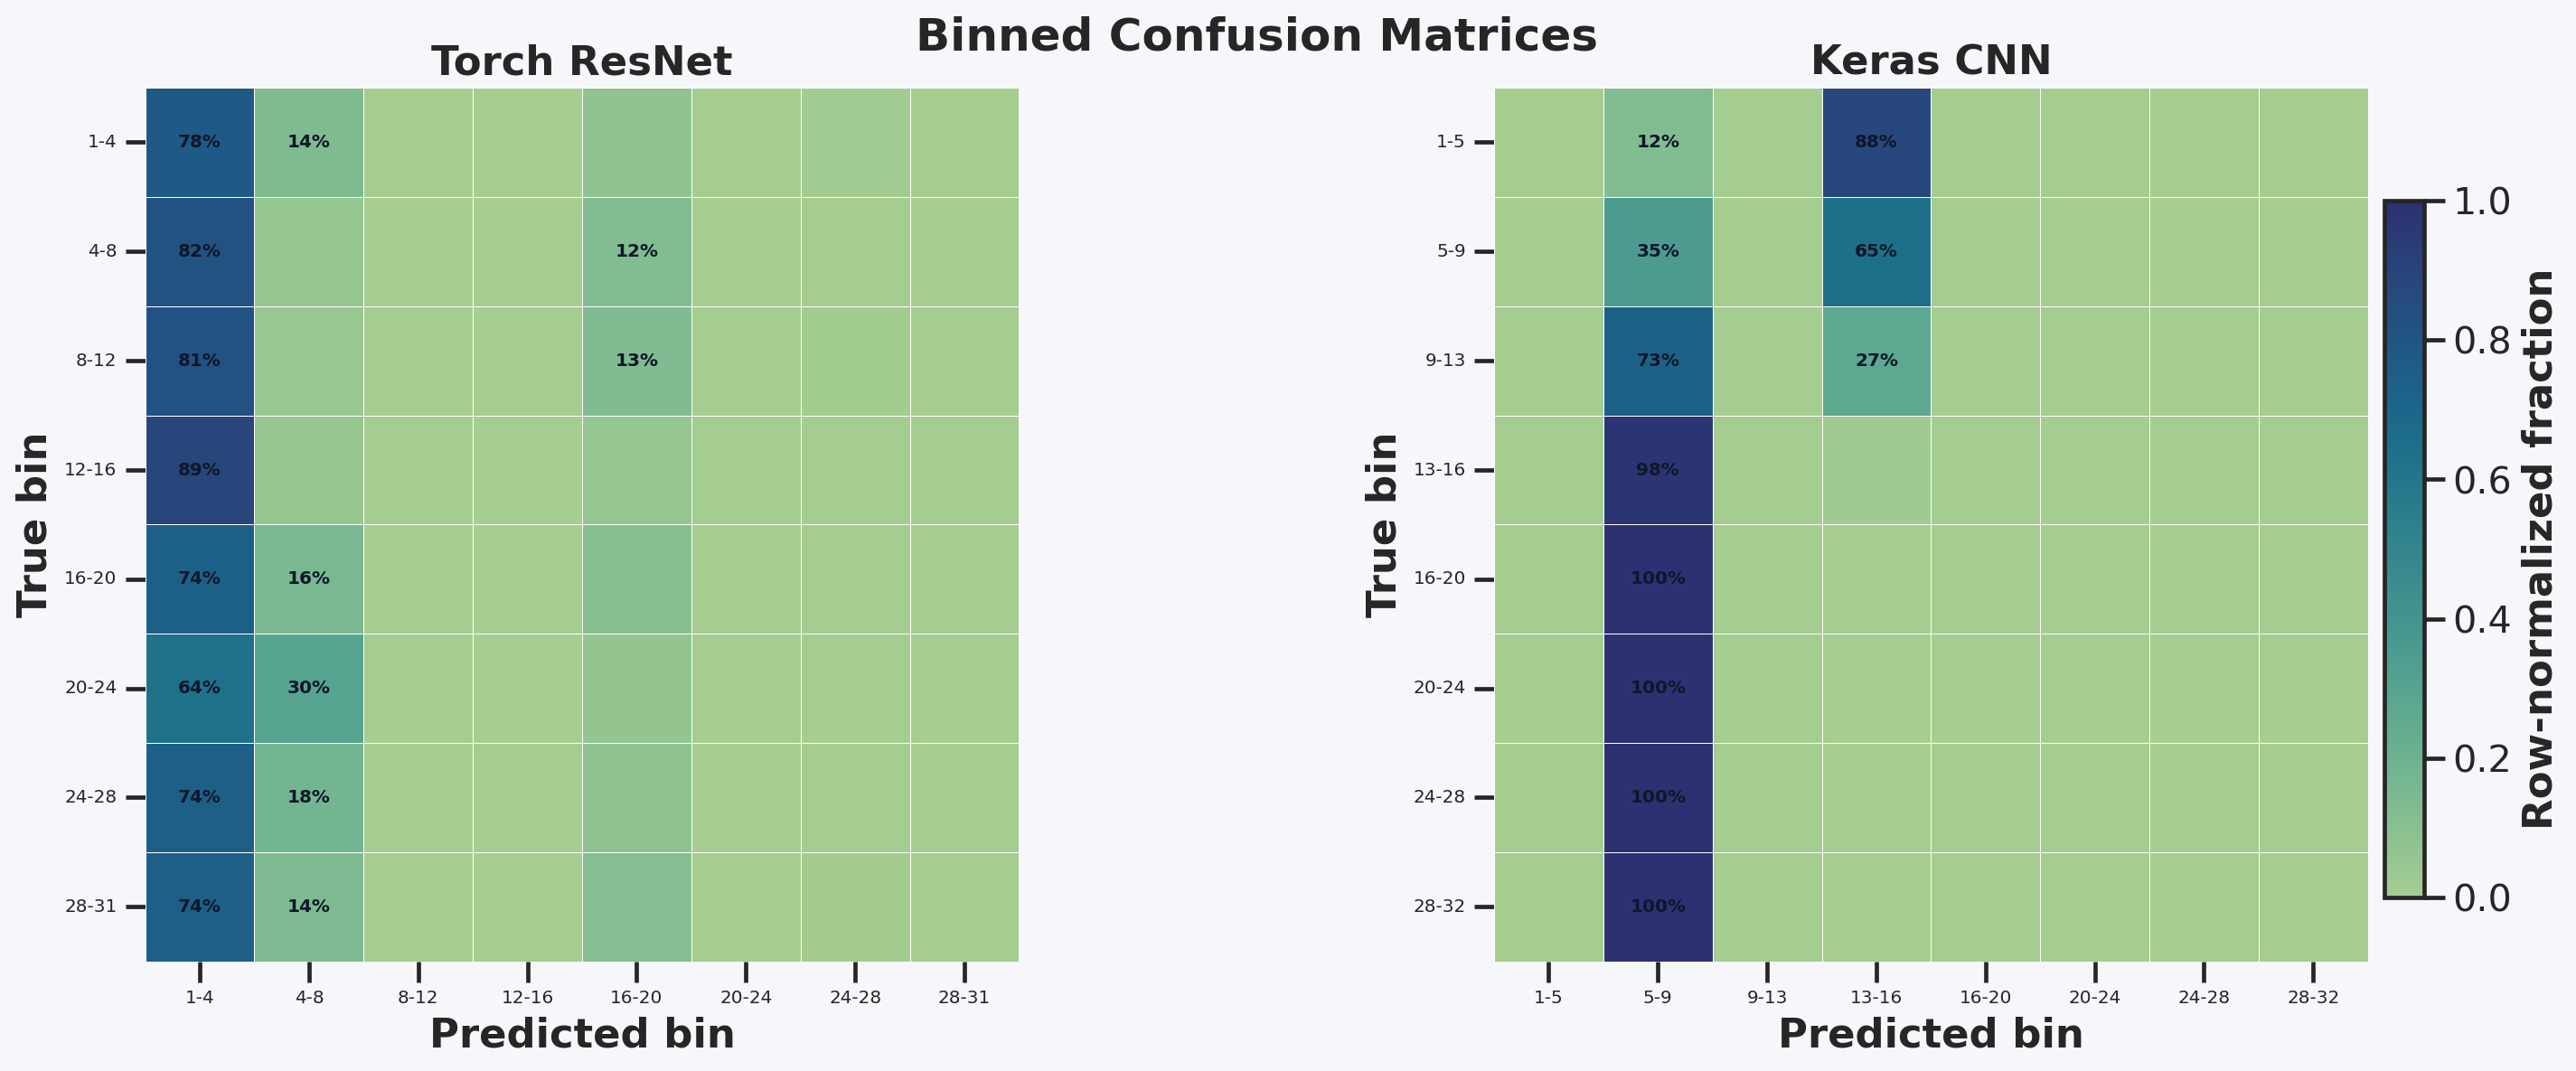

/home/davas/.uve/py311/lib/python3.11/site-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/tmp/ipykernel_18242/1519263701.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap_rgb = cm.get_cmap(cmap)(heatmap)[:,:,:3]
/home/davas/.uve/py311/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input']]
Received: inputs=['Tensor(shape=(1, 128, 128, 1))']
  warnings.warn(msg)


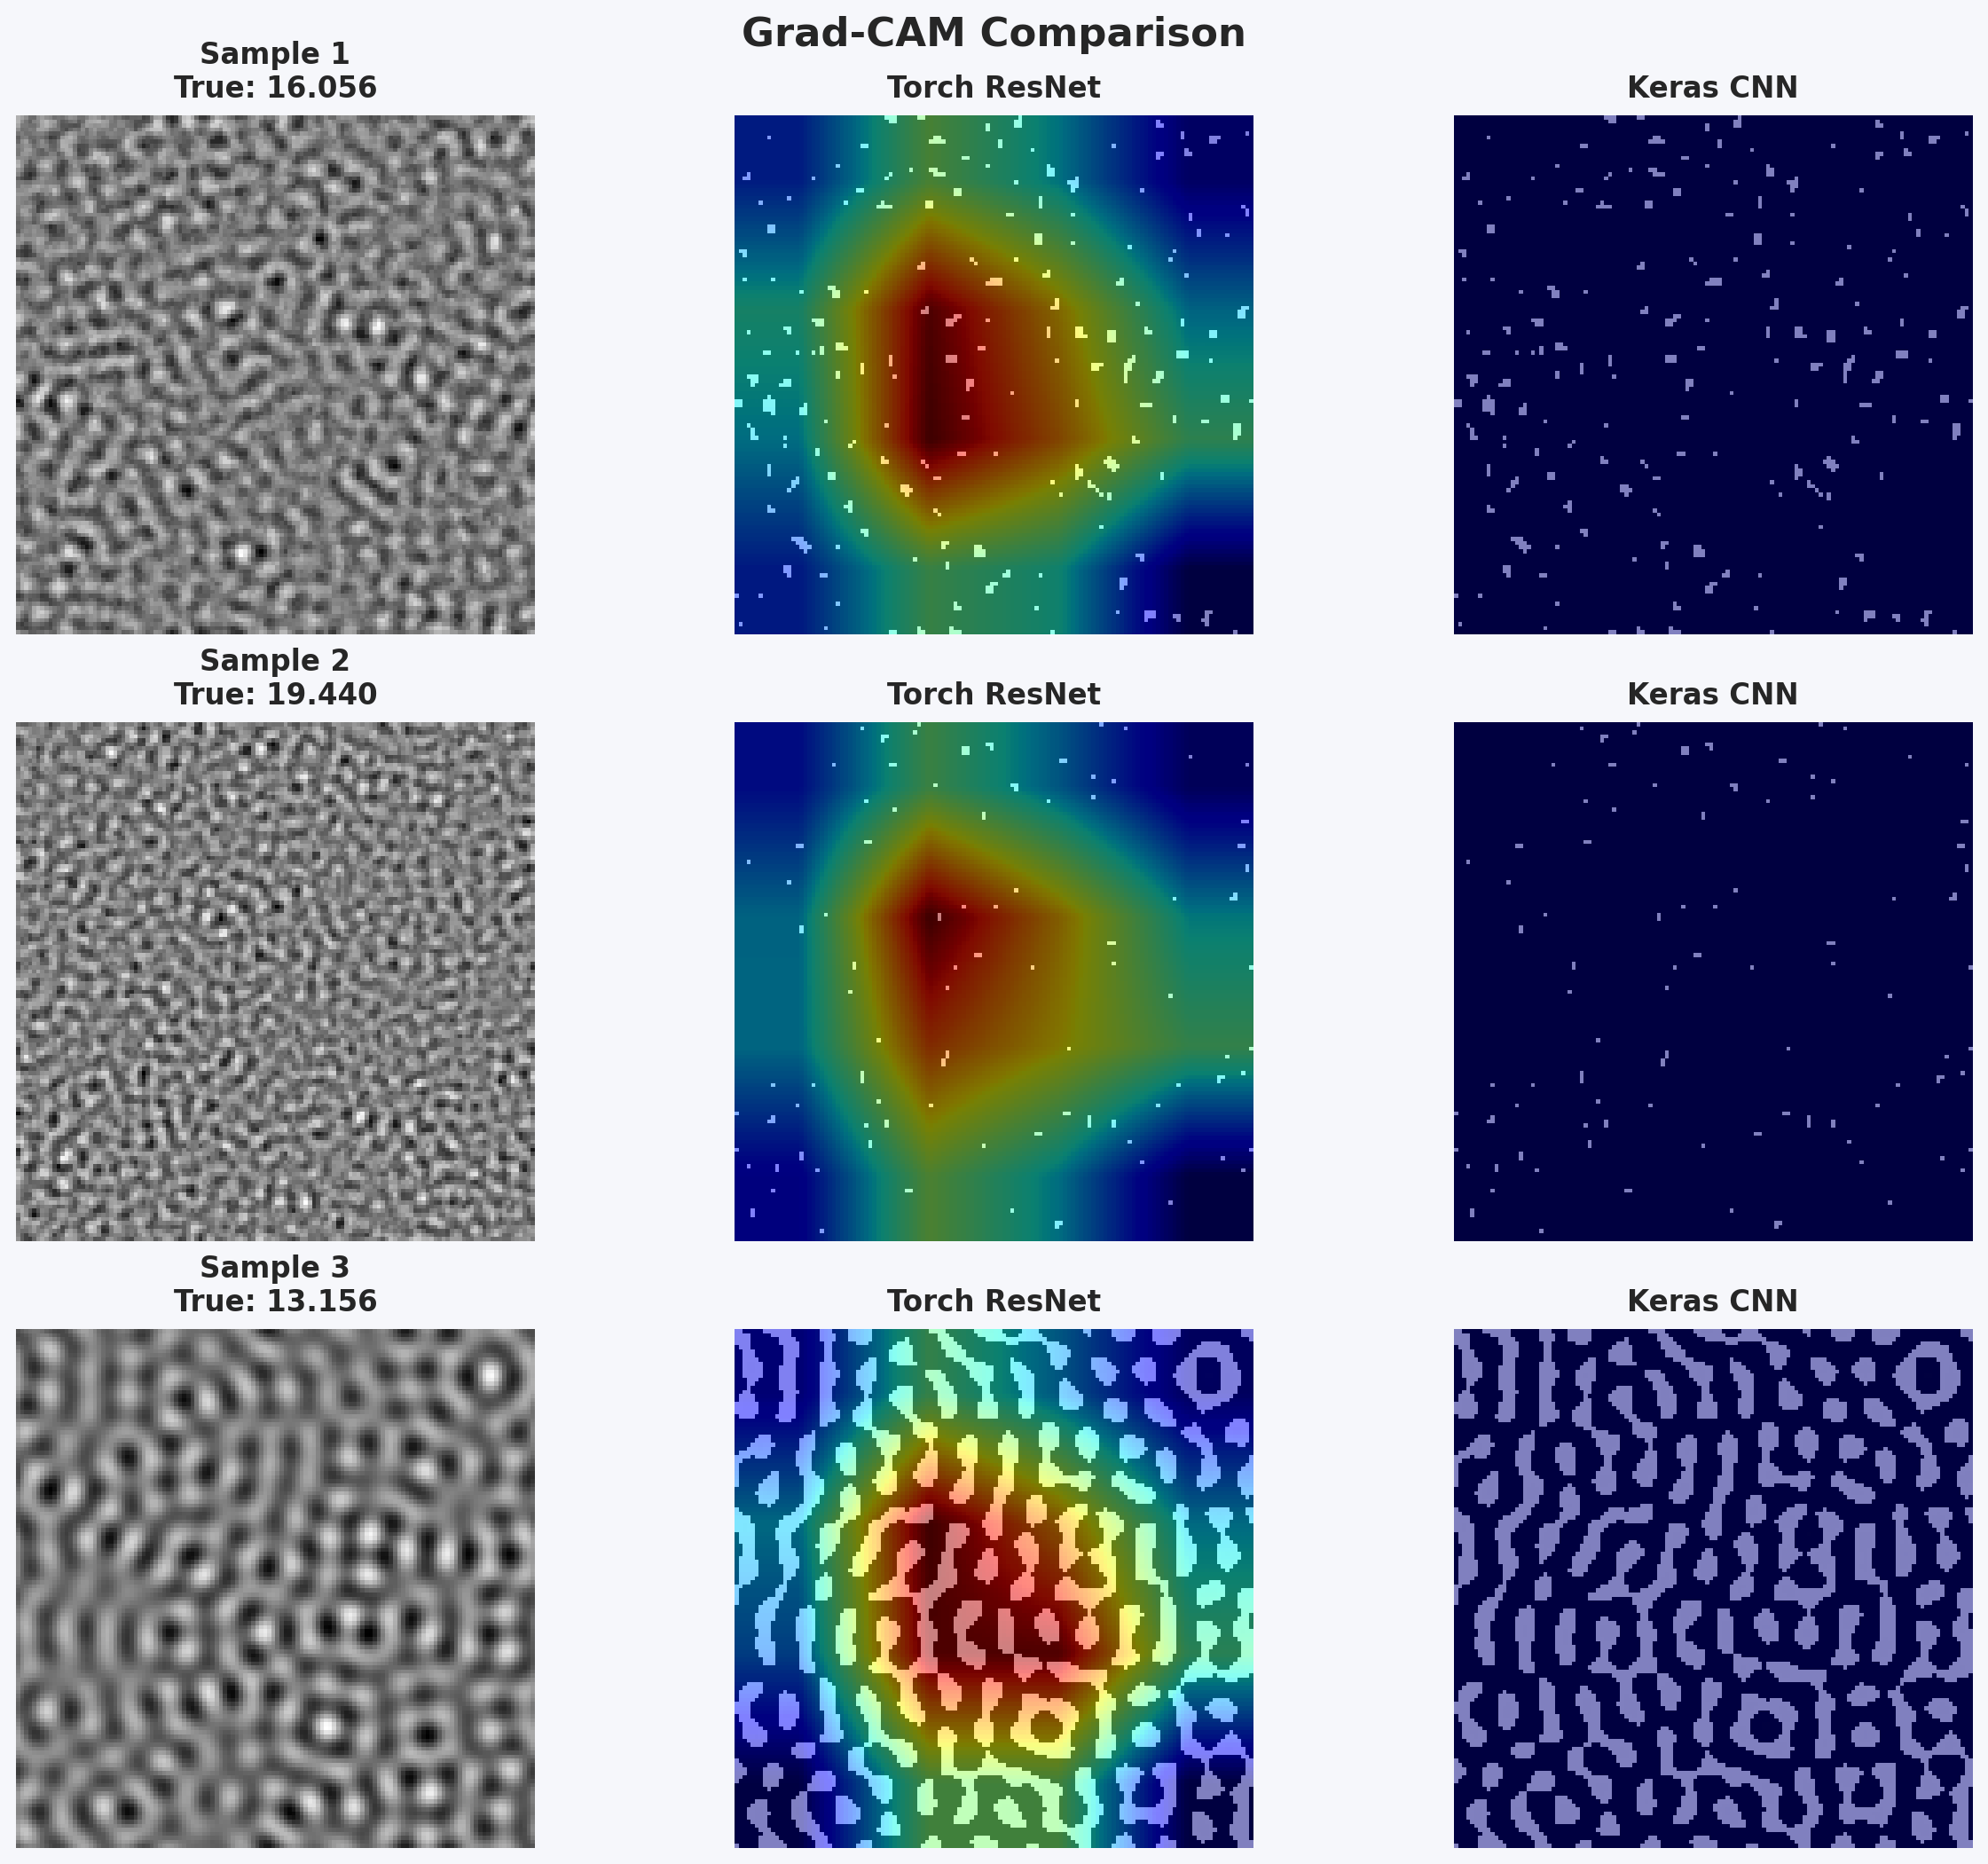

Saved poster figures to /home/davas/Documents/cnn_astro/outputs/comparison/gradcam


In [37]:
# Poster-ready plots for regression comparison
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks', context='talk')
plt.rcParams.update({
    'figure.dpi': 180,
    'savefig.dpi': 300,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'font.size': 11,
    'legend.frameon': False,
    'figure.facecolor': '#F6F7FB',
    'axes.facecolor': 'white',
})

plot_dir = OUTPUT_DIR
plot_dir.mkdir(parents=True, exist_ok=True)

# Ensure arrays are present and 1D
true_torch = np.asarray(all_torch_targets).reshape(-1)
pred_torch = np.asarray(all_torch_preds).reshape(-1)
true_tf = np.asarray(tf_targets).reshape(-1) if 'tf_targets' in globals() else None
pred_tf = np.asarray(tf_pred_vals).reshape(-1) if 'tf_pred_vals' in globals() else None


def _safe_concat(arrays):
    usable = []
    for arr in arrays:
        if arr is None:
            continue
        arr = np.asarray(arr).reshape(-1)
        if arr.size:
            usable.append(arr)
    return np.concatenate(usable) if usable else np.array([])


def _format_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#9CA3AF')
    ax.spines['bottom'].set_color('#9CA3AF')
    ax.grid(True, color='#D8D8D8', linewidth=0.8, alpha=0.65)


def _prepare_binned_confusion(y_true, y_pred, n_bins=8):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    combined = _safe_concat([y_true, y_pred])
    if combined.size == 0:
        return None, None

    lo = float(np.nanmin(combined))
    hi = float(np.nanmax(combined))
    if not np.isfinite(lo) or not np.isfinite(hi):
        return None, None
    if hi <= lo:
        hi = lo + 1.0

    edges = np.quantile(y_true, np.linspace(0.0, 1.0, n_bins + 1))
    edges = np.unique(edges)
    if edges.size < 3:
        edges = np.linspace(lo, hi, n_bins + 1)

    bins = len(edges) - 1
    if bins < 2:
        return None, None

    def _bin(values):
        values = np.asarray(values).reshape(-1)
        return np.clip(np.digitize(values, edges[1:-1], right=True), 0, bins - 1)

    true_bins = _bin(y_true)
    pred_bins = _bin(y_pred)
    cm = np.zeros((bins, bins), dtype=np.float64)
    for t, p in zip(true_bins, pred_bins):
        cm[int(t), int(p)] += 1.0
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums > 0)

    labels = []
    for i in range(bins):
        labels.append(f'{edges[i]:.0f}-{edges[i+1]:.0f}')
    return cm_norm, labels


# 1) Clean metrics + parity + residual panel
metric_names = ['MAE', 'RMSE']
torch_vals = [torch_metrics.get('mae', np.nan), torch_metrics.get('rmse', np.nan)]
tf_vals = [tf_metrics.get('mae', np.nan), tf_metrics.get('rmse', np.nan)] if 'tf_metrics' in globals() and tf_metrics else [np.nan, np.nan]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.4), constrained_layout=True)
fig.patch.set_facecolor('#F6F7FB')
fig.suptitle('Fractal Model Comparison on 10k Dataset', fontsize=20, fontweight='bold', y=1.02)

# Metrics bars
ax = axes[0]
bar_x = np.arange(len(metric_names))
bar_w = 0.34
bars_1 = ax.bar(bar_x - bar_w/2, torch_vals, width=bar_w, label='Torch ResNet', color='#2C7FB8')
bars_2 = ax.bar(bar_x + bar_w/2, tf_vals, width=bar_w, label='Keras CNN', color='#F28E2B')
ax.set_xticks(bar_x)
ax.set_xticklabels(metric_names)
ax.set_ylabel('Error')
ax.set_title('Regression Metrics')
ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
for bars in (bars_1, bars_2):
    ax.bar_label(bars, labels=[f'{b.get_height():.2f}' for b in bars], padding=3, fontsize=10)
_format_axis(ax)

# Parity plot
ax = axes[1]
if true_torch.size and pred_torch.size:
    ax.hexbin(true_torch, pred_torch, gridsize=32, cmap='Blues', mincnt=1, linewidths=0, alpha=0.9, label='Torch ResNet')
if true_tf is not None and pred_tf is not None and true_tf.size and pred_tf.size:
    ax.scatter(true_tf, pred_tf, s=10, alpha=0.20, color='#F28E2B', edgecolors='none', label='Keras CNN')
all_vals = _safe_concat([true_torch, pred_torch, true_tf, pred_tf])
if all_vals.size:
    lo = float(np.percentile(all_vals, 1))
    hi = float(np.percentile(all_vals, 99))
    if hi <= lo:
        hi = lo + 1.0
    ax.plot([lo, hi], [lo, hi], linestyle='--', color='#111827', linewidth=1.5, alpha=0.8)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('True value')
ax.set_ylabel('Predicted value')
ax.set_title('Prediction Parity')
ax.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0))
_format_axis(ax)

# Residuals
ax = axes[2]
if true_torch.size and pred_torch.size:
    residual_torch = pred_torch - true_torch
    sns.kdeplot(residual_torch, ax=ax, label='Torch ResNet', color='#2C7FB8', fill=True, alpha=0.22, linewidth=2.0)
if true_tf is not None and pred_tf is not None and true_tf.size and pred_tf.size:
    residual_tf = pred_tf - true_tf
    sns.kdeplot(residual_tf, ax=ax, label='Keras CNN', color='#F28E2B', fill=True, alpha=0.22, linewidth=2.0)
ax.axvline(0, color='#111827', linestyle='--', linewidth=1.2)
ax.set_xlabel('Prediction - True')
ax.set_ylabel('Density')
ax.set_title('Residual Spread')
ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
_format_axis(ax)

fig.savefig(plot_dir / 'poster_summary_clean_v2.png', bbox_inches='tight')
fig.savefig(plot_dir / 'poster_summary_clean_v2.pdf', bbox_inches='tight')
plt.show()

# 2) Binned confusion matrices for continuous labels
# This uses quantile bins so the matrix is interpretable for regression targets.
if true_torch.size and pred_torch.size:
    torch_cm, cm_labels = _prepare_binned_confusion(true_torch, pred_torch, n_bins=8)
else:
    torch_cm, cm_labels = None, None

if true_tf is not None and pred_tf is not None and true_tf.size and pred_tf.size:
    tf_cm, tf_cm_labels = _prepare_binned_confusion(true_tf, pred_tf, n_bins=8)
else:
    tf_cm, tf_cm_labels = None, None

if torch_cm is not None or tf_cm is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16.5, 6.3), constrained_layout=True)
    fig.patch.set_facecolor('#F6F7FB')
    fig.suptitle('Binned Confusion Matrices', fontsize=20, fontweight='bold', y=1.02)

    matrices = [
        (torch_cm, cm_labels, 'Torch ResNet', '#2C7FB8'),
        (tf_cm, tf_cm_labels, 'Keras CNN', '#F28E2B'),
    ]
    for ax, (cm_norm, labels_out, title, color) in zip(axes, matrices):
        if cm_norm is None:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
            ax.axis('off')
            continue
        annot = np.where(cm_norm >= 0.12, np.vectorize(lambda x: f'{x:.0%}')(cm_norm), '')
        sns.heatmap(
            cm_norm,
            ax=ax,
            cmap='crest',
            vmin=0.0,
            vmax=1.0,
            square=True,
            cbar=False,
            annot=annot,
            fmt='',
            annot_kws={'fontsize': 8, 'weight': 'bold', 'color': '#0F172A'},
            xticklabels=labels_out,
            yticklabels=labels_out,
            linewidths=0.4,
            linecolor='white',
        )
        ax.set_title(title)
        ax.set_xlabel('Predicted bin')
        ax.set_ylabel('True bin')
        ax.tick_params(axis='x', labelrotation=0, labelsize=8)
        ax.tick_params(axis='y', labelrotation=0, labelsize=8)
        _format_axis(ax)

    cbar_ax = fig.add_axes([0.92, 0.16, 0.015, 0.68])
    sm = plt.cm.ScalarMappable(cmap='crest', norm=plt.Normalize(vmin=0.0, vmax=1.0))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label='Row-normalized fraction')
    fig.savefig(plot_dir / 'poster_confusion_binned_v2.png', bbox_inches='tight')
    fig.savefig(plot_dir / 'poster_confusion_binned_v2.pdf', bbox_inches='tight')
    plt.show()

# 3) Tighter Grad-CAM comparison strip
n_strip = min(3, len(TEST_INDICES))
fig, axes = plt.subplots(n_strip, 3, figsize=(13.5, 3.8 * n_strip), constrained_layout=True)
fig.patch.set_facecolor('#F6F7FB')
if n_strip == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n_strip):
    idx_img = int(TEST_INDICES[row])
    with h5py.File(H5_PATH, 'r') as f:
        img = f['images'][idx_img]

    base_img = np.asarray(img, dtype=np.float32)
    if base_img.max() > 1.0:
        base_img = base_img / 255.0
    if base_img.ndim == 3:
        base_img = base_img[..., 0]

    t_img = np.asarray(img, dtype=np.float32)
    if t_img.ndim == 2:
        t_img = t_img[..., np.newaxis]
    elif t_img.ndim == 3 and t_img.shape[-1] != 1:
        t_img = t_img[..., 0:1]
    t_tensor = torch.from_numpy(t_img).permute(2, 0, 1).to(DEVICE)
    torch_cam = get_gradcam_torch(torch_model, t_tensor, target_class=None)
    torch_overlay = overlay_heatmap(base_img, torch_cam)

    tf_overlay = None
    if keras_model is not None:
        tf_img = np.asarray(img, dtype=np.float32)
        if tf_img.max() > 1.0:
            tf_img = tf_img / 255.0
        if tf_img.ndim == 2:
            tf_img = tf_img[..., np.newaxis]
        elif tf_img.ndim == 3 and tf_img.shape[-1] != 1:
            tf_img = tf_img[..., 0:1]
        tf_cam = get_gradcam_tf(keras_model, tf_img)
        tf_overlay = overlay_heatmap(tf_img[..., 0], tf_cam)

    axes[row, 0].imshow(base_img, cmap='gray', interpolation='nearest')
    axes[row, 0].set_title(f'Sample {row + 1}\nTrue: {float(labels[idx_img]):.3f}', fontsize=13, pad=8)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(torch_overlay, interpolation='nearest')
    axes[row, 1].set_title('Torch ResNet', fontsize=13, pad=8)
    axes[row, 1].axis('off')

    if tf_overlay is not None:
        axes[row, 2].imshow(tf_overlay, interpolation='nearest')
        axes[row, 2].set_title('Keras CNN', fontsize=13, pad=8)
    else:
        axes[row, 2].text(0.5, 0.5, 'Keras model unavailable', ha='center', va='center')
    axes[row, 2].axis('off')

fig.suptitle('Grad-CAM Comparison', fontsize=18, fontweight='bold', y=1.01)
fig.savefig(plot_dir / 'poster_gradcam_clean_v2.png', bbox_inches='tight')
fig.savefig(plot_dir / 'poster_gradcam_clean_v2.pdf', bbox_inches='tight')
plt.show()

print('Saved poster figures to', plot_dir)


## Metrics Table

The next cell creates a compact poster-friendly table with the key performance numbers for both models.

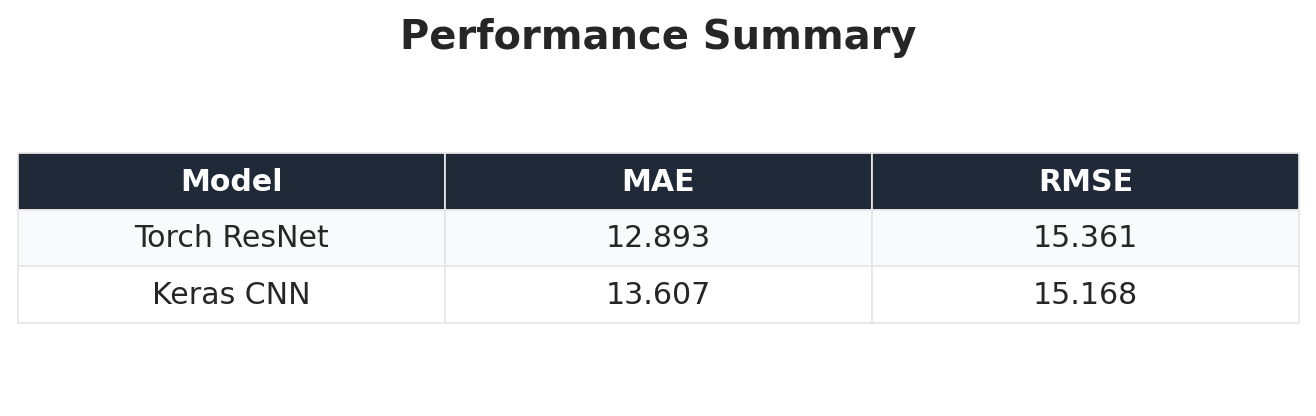

Saved metrics table to /home/davas/Documents/cnn_astro/outputs/comparison/gradcam


In [35]:
# Poster-friendly performance table
import pandas as pd

metrics_rows = []
metrics_rows.append({
    'Model': 'Torch ResNet',
    'MAE': float(torch_metrics.get('mae', np.nan)),
    'RMSE': float(torch_metrics.get('rmse', np.nan)),
})
if isinstance(tf_metrics, dict):
    metrics_rows.append({
        'Model': 'Keras CNN',
        'MAE': float(tf_metrics.get('mae', np.nan)),
        'RMSE': float(tf_metrics.get('rmse', np.nan)),
    })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df['MAE'] = metrics_df['MAE'].map(lambda x: f'{x:.3f}')
metrics_df['RMSE'] = metrics_df['RMSE'].map(lambda x: f'{x:.3f}')
metrics_df

fig, ax = plt.subplots(figsize=(7.2, 2.2), constrained_layout=True)
ax.axis('off')
table = ax.table(
    cellText=metrics_df.values,
    colLabels=metrics_df.columns,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.0, 1.8)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#E6E6E6')
    cell.set_linewidth(0.7)
    if row == 0:
        cell.set_facecolor('#1F2937')
        cell.set_text_props(color='white', weight='bold')
    elif row % 2 == 1:
        cell.set_facecolor('#F8FAFC')
    else:
        cell.set_facecolor('white')

ax.set_title('Performance Summary', fontsize=16, fontweight='bold', pad=12)
fig.savefig(plot_dir / 'poster_metrics_table.png', bbox_inches='tight')
fig.savefig(plot_dir / 'poster_metrics_table.pdf', bbox_inches='tight')
plt.show()

print('Saved metrics table to', plot_dir)
